# Multi-agent supervisor

The [previous example](../multi-agent-collaboration) routed messages automatically based on the output of the initial researcher agent.

We can also choose to use an [LLM to orchestrate](https://langchain-ai.github.io/langgraph/concepts/multi_agent/#supervisor) the different agents.

Below, we will create an agent group, with an agent supervisor to help delegate tasks.

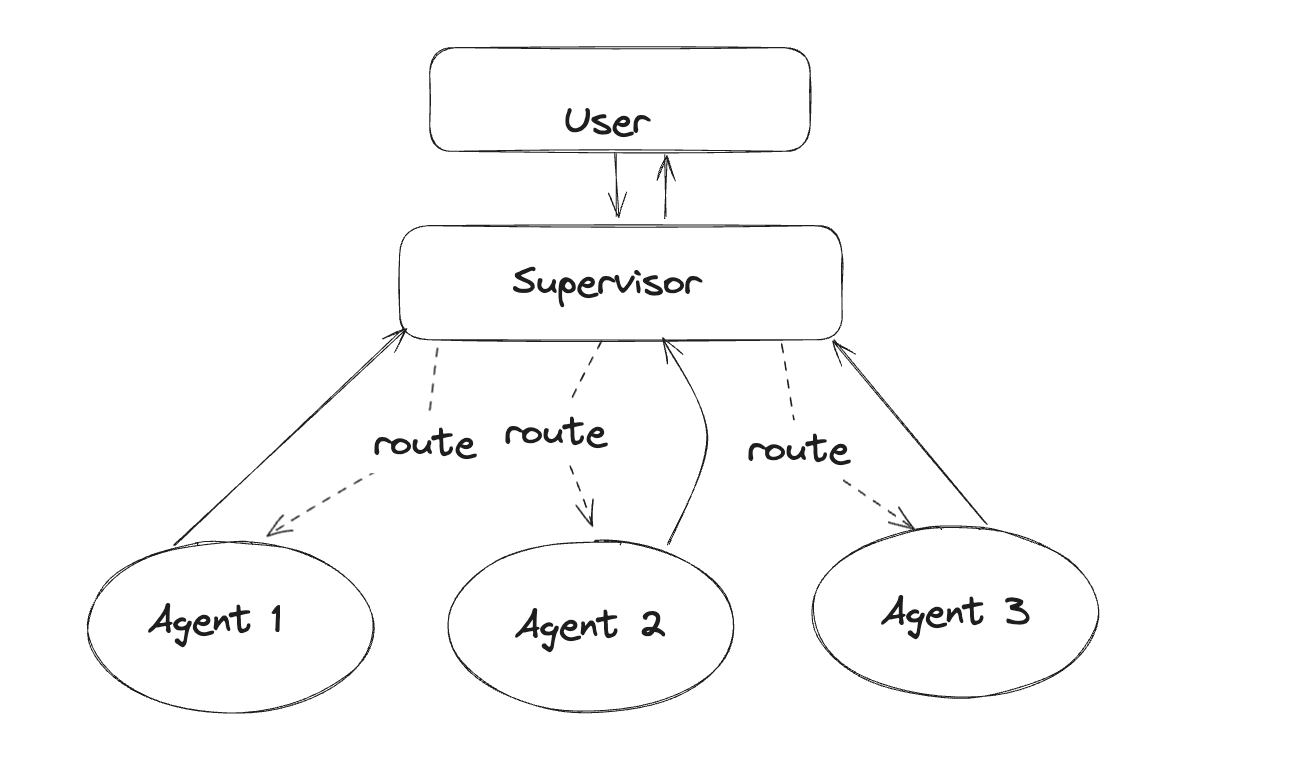

To simplify the code in each agent node, we will use LangGraph's prebuilt [create_react_agent](https://langchain-ai.github.io/langgraph/reference/prebuilt/#langgraph.prebuilt.chat_agent_executor.create_react_agent). This and other "advanced agent" notebooks are designed to show how you can implement certain design patterns in LangGraph. If the pattern suits your needs, we recommend combining it with some of the other fundamental patterns described elsewhere in the docs for best performance.

## Setup

First, let's install required packages and set our API keys

<div class="admonition tip">
    <p class="admonition-title">Set up <a href="https://smith.langchain.com">LangSmith</a> for LangGraph development</p>
    <p style="padding-top: 5px;">
        Sign up for LangSmith to quickly spot issues and improve the performance of your LangGraph projects. LangSmith lets you use trace data to debug, test, and monitor your LLM apps built with LangGraph — read more about how to get started <a href="https://docs.smith.langchain.com">here</a>. 
    </p>
</div>

## Create tools

For this example, you will make an agent to do web research with a search engine, and one agent to create plots. Define the tools they'll use below:

In [1]:
from typing import Annotated

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

tavily_tool = TavilySearchResults(max_results=5)

# This executes code locally, which can be unsafe
repl = PythonREPL()


@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code and do math. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    return result_str

### Create Agent Supervisor

It will use LLM with structured output to choose the next worker node OR finish processing.

In [ ]:
from typing import Literal
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langgraph_main.graph import MessagesState, END
from langgraph_main.types import Command


members = ["researcher", "coder"]
# Our team supervisor is an LLM node. It just picks the next agent to process
# and decides when the work is completed
options = members + ["FINISH"]

system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    f" following workers: {members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)


class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""

    next: Literal[*options]


llm = ChatGroq(
    model="qwen-qwq-32b",
    temperature=0,
    stop_sequences=None,
)


class State(MessagesState):
    next: str


def supervisor_node(state: State) -> Command[Literal[*members, "__end__"]]:
    messages = [
        {"role": "system", "content": system_prompt},
    ] + state["messages"]
    response = llm.with_structured_output(Router).invoke(messages)
    goto = response["next"]
    if goto == "FINISH":
        goto = END

    return Command(goto=goto, update={"next": goto})

## Construct Graph

We're ready to start building the graph. Below, define the state and worker nodes using the function we just defined.

In [3]:
from langchain import hub
prompt = hub.pull("hwchase17/react")
prompt

PromptTemplate(input_variables=['agent_scratchpad', 'input', 'tool_names', 'tools'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'hwchase17', 'lc_hub_repo': 'react', 'lc_hub_commit_hash': 'd15fe3c426f1c4b3f37c9198853e4a86e20c425ca7f4752ec0c9b0e97ca7ea4d'}, template='Answer the following questions as best you can. You have access to the following tools:\n\n{tools}\n\nUse the following format:\n\nQuestion: the input question you must answer\nThought: you should always think about what to do\nAction: the action to take, should be one of [{tool_names}]\nAction Input: the input to the action\nObservation: the result of the action\n... (this Thought/Action/Action Input/Observation can repeat N times)\nThought: I now know the final answer\nFinal Answer: the final answer to the original input question\n\nBegin!\n\nQuestion: {input}\nThought:{agent_scratchpad}')

In [ ]:
from langchain_core.messages import HumanMessage
from langgraph_main.graph import StateGraph, START, END
from langchain.agents import create_react_agent, AgentExecutor
from langchain_core.prompts import ChatPromptTemplate



research_agent = create_react_agent(
    llm, tools=[tavily_tool], prompt=prompt
)

agente_executor_research = AgentExecutor.from_agent_and_tools(agent=research_agent, tools=[tavily_tool])


def research_node(state: State) -> Command[Literal["supervisor"]]:
    result = agente_executor_research.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="researcher")
            ]
        },
        goto="supervisor",
    )



code_agent = create_react_agent(llm, tools=[python_repl_tool], prompt=prompt)

code_agent_executor = AgentExecutor.from_agent_and_tools(agent = code_agent, tools=[python_repl_tool]) 


def code_node(state: State) -> Command[Literal["supervisor"]]:
    result = code_agent_executor.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="coder")
            ]
        },
        goto="supervisor",
    )


builder = StateGraph(State)
builder.add_edge(START, "supervisor")
builder.add_node("supervisor", supervisor_node)
builder.add_node("researcher", research_node)
builder.add_node("coder", code_node)
graph = builder.compile()

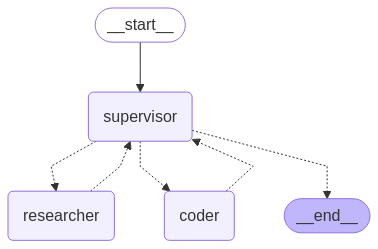

In [5]:
## docker run -p 3000:3000 ghcr.io/jihchi/mermaid.ink 
from IPython.display import display, Image
import nest_asyncio

nest_asyncio.apply()

display(Image(graph.get_graph().draw_mermaid_png()))

## Invoke the team

With the graph created, we can now invoke it and see how it performs!

In [6]:
"""for s in graph.stream(
    {"messages": [("user", "What's the square root of 42?",
                    )]}, subgraphs=True
):
    print(s)
    print("----")"""

'for s in graph.stream(\n    {"messages": [("user", "What\'s the square root of 42?",\n                    )]}, subgraphs=True\n):\n    print(s)\n    print("----")'

In [7]:
"""for s in graph.stream(
    {
        "messages": [
            (
                "user",
                "Find the latest GDP of New York and California, then calculate the average",
            )
        ]
    },
    subgraphs=True,
):
    print(s)
    print("----")"""

'for s in graph.stream(\n    {\n        "messages": [\n            (\n                "user",\n                "Find the latest GDP of New York and California, then calculate the average",\n            )\n        ]\n    },\n    subgraphs=True,\n):\n    print(s)\n    print("----")'

# Testando

In [10]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from chat_bots import (
                      ChatValuationAsync,
                      ChatFundamentalistasAsync,
                      ChatSentimentoAsync,
                      ChatAnaliseTecnicaAsync)
from tratando_dados import TratandoDadosIndicadores, TratandoDadosValuation, TratarDadosNoticias, tratando_dados_fundamentalistas
from chat_bots import get_secret_key
from pydantic import SecretStr
from typing import Iterator, List, Any
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from selenium import webdriver
import warnings
import pandas as pd
import asyncio
warnings.filterwarnings('ignore')

load_dotenv()

try:
    api_secret_groq = get_secret_key("GROQ_API_KEY")
except KeyError as exc:
    raise ValueError("API key inválida ou não definida") from exc

api_key = os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    api_key=api_key,
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    #model="qwen-2.5-coder-32b",
    temperature=0,
    stop_sequences=None,
)

memory = MemorySaver()


class State(TypedDict):
    messages: Annotated[list, add_messages]
    ticker: str
    method_analysis: list[str]
    dados_input : str
    next: str
    
    
class ModeloAnaliseTecnicaAsync():
    def __init__(
        self,
        query: str,
        ticker: str,
        periodo: str = "18Y",
        intervalo: str = "1mo",
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        stream: bool = False,
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        self.query = query
        self.ticker = ticker
        self.periodo = periodo
        self.intervalo = intervalo
        self.modelo_llm = modelo_llm
        self.stream = stream
        self.api_secret = api_secret

    def dados_indicadores_tecnicas(self) -> List[Any]:
        ind = TratandoDadosIndicadores(
            ticker=self.ticker, periodo=self.periodo, intervalo=self.intervalo
        )
        return ind.indicadores_data_loader()

    async def chat_analise_tecnica(self) -> str | Iterator[str]:
        dados_tecnicas = self.dados_indicadores_tecnicas()
        response = await ChatAnaliseTecnicaAsync(
            query=self.query,
            dados=dados_tecnicas,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
            response = response.split('</think>')[1]
        return response

class ModeloValuationAsync:
    def __init__(
        self,
        ticker: str,
        query: str,
        anos_projecao: int = 5,
        taxa_crescimento_perpetuidade: float = 0.014,
        calculo_necessidade_capital_de_giro: bool = False,
        stream: bool = False,
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        self.query = query
        self.ticker = ticker
        self.anos_projecao = anos_projecao
        self.taxa_crescimento_perpetuidade = taxa_crescimento_perpetuidade
        self.calculo_necessidade_capital_de_giro = calculo_necessidade_capital_de_giro
        self.stream = stream
        self.modelo_llm = modelo_llm
        self.api_secret = api_secret

    def tratando_ticker(self) -> str:
        if ".SA" in self.ticker:
            acao = self.ticker
        else:
            acao = f"{self.ticker}.SA"
        return acao

    def dados_valuation(self) -> tuple[str, str, str, str]:
        dados_valu = TratandoDadosValuation(
            ticker=self.tratando_ticker(),
            anos_projecao=5,
            taxa_crescimento_perpetuidade=self.taxa_crescimento_perpetuidade,
            calculo_necessidade_capital_de_giro=self.calculo_necessidade_capital_de_giro,
        )
        markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores = (
            dados_valu.dados_valuation()
        )
        return markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores

    async def chat_valuation(self) -> str | Iterator[str]:
        markdow_gordon, markdow_fluxo, markdow_preco, markdow_indicadores = (
            self.dados_valuation()
        )

        response = await ChatValuationAsync(
            query=self.query,
            precos_atual_valuations=markdow_preco,
            indicadores_valuation_fluxo=markdow_indicadores,
            valuation_metodo_gordon=markdow_gordon,
            valuation_fluxo_caixa=markdow_fluxo,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
            response = response.split('</think>')[1]

        return response
    

class ModeloSentimentoAsync:
    def __init__(
        self,
        ticker: str,
        query: str,
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        stream: bool = False,
        api_secret_groq: SecretStr | None = api_secret_groq,
        api_secret_serper: SecretStr | None = None,
    ) -> None:
        self.ticker = ticker
        self.query = query
        self.modelo_llm = modelo_llm
        self.stream = stream
        self.api_secret_groq = api_secret_groq
        self.api_secret_serper = api_secret_serper

    def option(self) -> webdriver.ChromeOptions:
        chrome_options = webdriver.ChromeOptions()
        chrome_options.add_argument("--headless")
        chrome_options.add_argument("--no-sandbox")
        chrome_options.add_argument("--disable-dev-shm-usage")
        chrome_options.add_argument("--disable-gpu")
        chrome_options.add_argument("--disable-features=NetworkService")
        chrome_options.add_argument("--window-size=1920x1080")
        chrome_options.add_argument("--disable-features=VizDisplayCompositor")
        return chrome_options

    def dados_sentimento(self) -> str:
        dados_noticias = TratarDadosNoticias(
            acao=self.ticker,
            options=self.option(),
            api_secret_groq=self.api_secret_groq,
            api_secret_serper=self.api_secret_serper,
        )
        dados_new = dados_noticias.clean_chat_html_bs4()
        return dados_new

    async def chat_sentimento(self) -> str | Iterator[str]:
        dados_new = self.dados_sentimento()
        response = await ChatSentimentoAsync(
            query=self.query,
            noticia=dados_new,
            api_secret=self.api_secret_groq,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
            response = response.split('</think>')[1]
        return response


class ModeloFundamentosAsync:
    def __init__(
        self,
        ticker: str,
        query: str,
        stream: bool = False,
        modelo_llm: str = "meta-llama/llama-4-scout-17b-16e-instruct",
        dados_inicio: str = "2022-06-01",
        api_secret: SecretStr | None = api_secret_groq,
    ) -> None:
        
        self.query = query
        self.ticker = ticker
        self.stream = stream
        self.modelo_llm = modelo_llm
        self.dados_inicio = dados_inicio
        self.api_secret = api_secret

    async def dados_fundamentalistas(self) -> List[Any]:
        return await tratando_dados_fundamentalistas(self.ticker, self.dados_inicio)

    async def chat_fundamentalistas(self) -> str | Iterator[str]:
        dados_fundamentalistas = await self.dados_fundamentalistas()
        response = await ChatFundamentalistasAsync(
            query=self.query,
            dados=dados_fundamentalistas,
            api_secret=self.api_secret,
            modelo_llm=self.modelo_llm,
            stream=self.stream,
        )
        if '</think>' in response:
                response = response.split('</think>')[1]
        return response

In [11]:
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import MessagesState, END
from langgraph.types import Command
async def process_technical(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a análise técnica para o ticker especificado no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise técnica assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise técnica
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos techincal')
   
    ticker = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloAnaliseTecnicaAsync(ticker=ticker, query=query)
    response = await modelo.chat_analise_tecnica()
    
    dados_input = state['dados_input']
    
    if isinstance(dados_input, list):
        dados_input = dados_input[0].content
    
    response = dados_input + "\n" + response
    
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="tecnica")
            ]
        },
        goto="supervisor",
    )
    
    

async def process_valuation(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a análise de valuation para o ticker especificado no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de valuation assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise de valuation
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos valuation')
    
    ticker = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloValuationAsync(ticker=ticker, query=query)
    response = await modelo.chat_valuation()
    dados_input = state['dados_input']
    if isinstance(dados_input, list):
        dados_input = dados_input[0].content
    response = dados_input + "\n" + response
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="valuation")
            ]
        },
        goto="supervisor",
        )
    
        
    
    
async def process_sentimetal(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a análise de sentimento para o ticker especificado no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise de sentimento assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise de sentimento
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos sentimental')
    
    ticker = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloSentimentoAsync(ticker=ticker, query=query)
    response= await modelo.chat_sentimento()
    dados_input = state['dados_input']
    if isinstance(dados_input, list):
        dados_input = dados_input[0].content
    response = dados_input + "\n" + response
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="valuation")
            ]
        },
        goto="supervisor",
        )
        
    
async def process_fundamental(state: State) -> Command[Literal["supervisor"]]:
    """
    Executa a análise fundamentalista para o ticker especificado no estado.

    Recupera o ticker e a última mensagem do usuário do estado.
    Instancia e chama o modelo de análise fundamentalista assíncrono.
    Adiciona a resposta do modelo à lista 'dados_input' no estado.

    Args:
        state (State): O dicionário de estado atual, contendo 'ticker',
                       'messages' e 'dados_input'.

    Returns:
        Optional[State]: O estado atualizado com a resposta da análise fundamentalista
                         adicionada a 'dados_input', ou None se ocorrer um erro.
    """
    print('Entrei nos fundamentos')
    
    ticker = state['ticker']
    query = state["messages"][-1]
    modelo = ModeloFundamentosAsync(ticker=ticker, query=query)
    response = await modelo.chat_fundamentalistas()
    dados_input = state['dados_input']
    if isinstance(dados_input, list):
        dados_input = dados_input[0].content
    response = dados_input + "\n" + response
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="valuation")
            ]
        },
        goto="supervisor",
        )
    

async def analise_investimento(state: State) -> Command[Literal["supervisor"]]:
    print('entrei no analis investimento')
    ticker = state['ticker']

    tecnica = ModeloAnaliseTecnicaAsync(
            query=f"Qual a analise tecnica da {ticker}",
            ticker=ticker,
        )
    fundamentos = ModeloFundamentosAsync(
            query=f"Qual o fundamentos da {ticker}",
            ticker=ticker,
        
        )
    valuation = ModeloValuationAsync(
            query=f"Qual o valuation da {ticker}",
            ticker=ticker,
        )
    sentimento = ModeloSentimentoAsync(
            query=f"Qual o sentimento da {ticker}",
            ticker=ticker,
        )
     
    response = await asyncio.gather(
            tecnica.chat_analise_tecnica(),
            fundamentos.chat_fundamentalistas(),
            valuation.chat_valuation(),
            sentimento.chat_sentimento()
        )
        
    dados_input = state['dados_input']
    
    response = dados_input.join(response)
    return Command(
        update={"dados_input": [
                HumanMessage(content=response, name="valuation")
            ]
        },
        goto="supervisor",
        )

In [12]:
import json
async def chat_input(state: State) -> State:
    """
    Processa a última mensagem do usuário para identificar um ticker de ação e o método de análise solicitado.

    Esta função lê uma lista de empresas e seus tickers de uma fonte externa.
    Constrói um prompt para um modelo de linguagem grande (LLM) instruindo-o a extrair
    o ticker da ação e o tipo de análise (fundamentals,valuation, sentimental, technical, Analise_investimento, chatbot)
    da última mensagem do usuário no estado fornecido.

    A função envia o prompt e a mensagem do usuário para o LLM, analisa a resposta
    para extrair o ticker e o método. Realiza uma verificação básica para garantir
    que o ticker extraído seja válido ou encontra um semelhante se necessário.
    Finalmente, atualiza o dicionário de estado com o ticker identificado e o método
    de análise e retorna o estado atualizado.

    Args:
        state (State): Um dicionário representando o estado atual da conversa,
                       espera-se que contenha uma chave "messages" com uma lista
                       de mensagens, onde a última é a do usuário.

    Returns:
        State: O dicionário de estado atualizado com as chaves 'ticker' e
               'method_analysis' preenchidas com os valores extraídos da
               resposta do LLM. O ticker pode ser uma string vazia se nenhum
               for identificado. O método de análise será um dos seguintes:
               fundamentals,valuation,sentimental,technical,analise_investimento,chatbot.
    """
    
    print('Entrei na chat imput')
    
    empresas_df = pd.read_csv('https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv', encoding='utf-8')
    
    prompt = """
    Você é um assistente especializado em investimentos do mercado brasileiro. Extraia precisamente as seguintes informações:
    
    1. O ticker (código) da ação mencionada na mensagem do usuário. Se houver múltiplos tickers, identifique qual está sendo solicitado para análise.
    2. O método de análise desejado (fundamentals, valuation, sentimental, technical). 
    3. Se for dado exemplos parecido com "Analise essa petrobras" ou "Vale apena investir na vale" responda (analise_investimento).
    4. Se o usuário apenas mencionar uma empresa sem pedir análise específica, ainda extraia o ticker e defina o método como .
    5. Se não houver menção a nenhuma empresa ou ticker, retorne o método como "chatbot".
    
    Regras para identificação de tickers:
    - Tickers brasileiros geralmente terminam com números (ex: PETR4, VALE3)
    - Se o usuário mencionar apenas o nome da empresa (ex: "Petrobras"), identifique o ticker correto ({empresas_tickers})
    - Se houver ambiguidade, prefira o ticker mais líquido (geralmente terminados em 3 ou 4)
    - Se o usuário mencionar apenas o setor (ex: "bancos"), não retorne ticker específico
    
    Formato de resposta (apenas):
    <FORMATO RESPOSTAS>
    TICKER: [ticker em letras maiúsculas ou vazio se não identificado]
    MÉTODO: [Deve retornar strings, Caso haja mais de um método, separe-as strings por vírgula, ex: ["technical", "valuation"]]
    <FORMATO RESPOSTAS>
    """
    
    empresas_tickers = "\n".join([f"{empresa} ({ticker})" for empresa, ticker in 
                                zip(empresas_df['Empresa'], empresas_df['tic'])])
    prompt = prompt.format(empresas_tickers=empresas_tickers)
    
    # Pegar a última mensagem do usuário
    last_message = state["messages"][-1]
    
    # Fazer a chamada ao LLM
    response = await llm.ainvoke([
        HumanMessage(content=prompt),
        HumanMessage(content=last_message.content)
    ])
    
    response_text = response.content
    
    ticker = ''
    metodo_analise = 'chatbot'
    
    # Extração mais robusta
    for line in response_text.split('\n'):
        if line.startswith('TICKER:'):
            ticker = line.split(':')[1].strip()
        elif line.startswith('MÉTODO:'):
            metodo_analise = line.split(':')[1].strip()
    
    if isinstance(metodo_analise, str) and metodo_analise.startswith('['):
        metodo_analise = json.loads(metodo_analise)
    else:
        metodo_analise = [m.strip() for m in metodo_analise.split(',') if m.strip()]
    if ticker:
        if ticker not in empresas_df['tic'].values:
            similar_tickers = empresas_df[empresas_df['tic'].str.contains(ticker[:2])]['tic'].tolist()
            if similar_tickers:
                ticker = similar_tickers[0]
                
    print(f"Ticker extraído: {ticker}")
    print(f"Método de análise: {metodo_analise}")
    
    state['ticker'] = ticker
    state['method_analysis'] = metodo_analise
    
    return state

In [13]:
"""user_input = [
    # Saudações gerais
    "Bom dia, como está?",
    "Olá, poderia me ajudar?",
    "Boa tarde, gostaria de algumas análises",
    "Oi, preciso de ajuda com investimentos",
    
    # Análises Técnicas
    "Realize uma análise técnica da PETROBRAS",
    "Quero ver a análise técnica da VALE",
    "Me mostre os indicadores técnicos da ITUB4",
    "Poderia fazer uma análise técnica da Banco do BRASIL?",
    "Como está o gráfico técnico da MAGAZ LUIZA?",
    
    # Análises Fundamentalistas
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Preciso dos fundamentos da PETROBRAS",
    "Qual a análise fundamental da VALE?",
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Faça uma análise fundamentalista da ITAU",
    "Como estão os fundamentos da WEG?",
    
    # Análises de Sentimento
    "Qual o sentimento do mercado sobre Unifique?",
    "Análise de sentimento para VALE, por favor",
    "Como está o sentimento para MULTIPLAN?",
    "Faça uma análise de sentimento da OI",
    "Qual a percepção do mercado sobre PETZ?",
    
    # Análises de Valuation
    "Qual o valor justo da AMERICANAS?",
    "Faça uma análise de valuation do Banco do AMAZONIA",
    "Preciso do valuation da BANDO MERCANTIL",
    "Me ajude com o valuation da ECORODOVIAS",
    "Quanto vale realmente a CEMIG?",
    
    # Combinações de Análises
    "Quero análise técnica e fundamental da PETR4",
    "Mostre o sentimento e valuation da VALE3",
    "Preciso de uma análise completa da BBDC3",
    "Como está BRASKEM em termos técnicos e sentimentais?",

    
    # Perguntas Específicas
    
    "Qual o melhor momento para comprar PETR4?",
    "Devo vender minha posição em GERDAU?",
    "É hora de investir em BRAVA?",
    "FLEURY está cara ou barata?",
    "Vale a pena entrar em MAGAZIN LUIZA agora?"
]
config = {"configurable": {"thread_id": "1"}}
for mess in user_input:
        # Configuração inicial do estado
    print('Pergunta feita:',mess)
    
    initial_state = {
                "messages": [HumanMessage(content=mess)],
                "ticker": "", 
                "method_analysis": "" ,
                "dados_input" : "",
                "next" : ""
                
            }
    
    events = await chat_input(
                initial_state,
  
            )"""

'user_input = [\n    # Saudações gerais\n    "Bom dia, como está?",\n    "Olá, poderia me ajudar?",\n    "Boa tarde, gostaria de algumas análises",\n    "Oi, preciso de ajuda com investimentos",\n    \n    # Análises Técnicas\n    "Realize uma análise técnica da PETROBRAS",\n    "Quero ver a análise técnica da VALE",\n    "Me mostre os indicadores técnicos da ITUB4",\n    "Poderia fazer uma análise técnica da Banco do BRASIL?",\n    "Como está o gráfico técnico da MAGAZ LUIZA?",\n    \n    # Análises Fundamentalistas\n    "Me mostre os indicadores fundamentalistas da BRADESCO",\n    "Preciso dos fundamentos da PETROBRAS",\n    "Qual a análise fundamental da VALE?",\n    "Me mostre os indicadores fundamentalistas da BRADESCO",\n    "Faça uma análise fundamentalista da ITAU",\n    "Como estão os fundamentos da WEG?",\n    \n    # Análises de Sentimento\n    "Qual o sentimento do mercado sobre Unifique?",\n    "Análise de sentimento para VALE, por favor",\n    "Como está o sentimento para

In [14]:
async def chatbot(state: State) -> dict:
    """
    Gera uma resposta consolidada de análise de investimentos usando um LLM.

    Esta função constrói um prompt detalhado para um LLM (ChatGroq),
    fornecendo-lhe os resultados das análises anteriores (técnica, fundamentalista,
    sentimento, valuation) armazenados em `state['dados_input']` e a última
    mensagem do usuário de `state['messages']`.

    O LLM é instruído a agir como um assistente de investimentos, resumir
    cada tipo de análise, fornecer um comentário geral sobre o ativo,
    indicar um nível de confiança e considerações finais (incluindo riscos),
    formatando a saída em Markdown.

    Args:
        state (State): O dicionário de estado atual, que deve conter:
            - 'dados_input': Uma lista de strings, cada uma representando
                             o resultado de uma análise prévia, separadas
                             por marcadores específicos (ex: '###Technical Analysis###').
            - 'messages': Uma lista de mensagens da conversa, onde a última
                          é a consulta mais recente do usuário.
            - 'ticker': (Opcional) O ticker da ação sendo analisada.
            - 'method_analysis': (Opcional) O método de análise identificado.

    Returns:
        Dict[str, Any]: Um dicionário contendo a nova mensagem da IA ('messages'),
                        e preservando 'ticker', 'method_analysis', e 'dados_input'
                        do estado original. Em caso de erro durante o processamento,
                        a mensagem da IA conterá uma descrição do erro.
    """
    try:
        print('Entrei no chat bot')
        print('Dados input:', state['dados_input'])
        print(f"O tamanho do dados input é: {len(state['dados_input'])}")
        # Criar o prompt do sistema
        system_message = SystemMessage(content=f"""
       Você é um assistente especializado em análise de investimentos no mercado brasileiro.
        
        Voce recebe os seguintes dados 
        <DADOS INPUT>
        {state['dados_input']}.
        <DADOS INPUT>
        Nesses dados voce recebe informacao de analise técnica, analise fundamentalista, analise de sentimento e analise de valuation de acoes expecificado pelos usuarios.
        As analises nesses dados estao divididos pelo seguinte caracteres:
        - #########Technical Analysis#######  = Dentro dessa analise tem analise tecnica da acao.
        - ##########Fundamental Analysis######## = Dentro dessa analise tem a analise dos balancos da acao.
        - ############Valuation Analysis############ = Dentro dessa te a estimativa do valuation da acao.
        - #########Sentiment Analysis##### =  Dentro dessa temos a analise de noticias sobre a acao.
        
        Diretrizes:
        - Seja conciso e direto nas respostas
        - Use linguagem acessível, mas profissional
        - Quando não tiver certeza, admita as limitações
        - Sempre mencione os riscos envolvidos em investimentos
        - Evite recomendações diretas de compra/venda
        
        Voce deve dar o nivel de confianca da analise.
        Indique se analisando as entradas do agentes, a recomendacao e de compra, venda ou manter a acao.
    
        
        """)
        
        # Pegar a última mensagem do usuário
        last_message = state["messages"][-1]
        
        
        # Montar a lista de mensagens para o LLM
        messages = [
            system_message,
            HumanMessage(content=f"{last_message.content}")
        ]
        
        llm = ChatGroq(
        api_key=api_key,
        #model="meta-llama/llama-4-scout-17b-16e-instruct",
        model="qwen-qwq-32b",
        temperature=0,
        stop_sequences=None,
    )
        
        # Fazer a chamada ao LLM
        response = await llm.ainvoke(messages)
        
        # Retornar o estado atualizado
        return {
            "messages": [AIMessage(content=response.content)],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
            "dados_input": state.get('dados_input', "")
        }
        
    except Exception as e:
        return {
            "messages": [AIMessage(content=f"Erro no processamento: {str(e)}")],
            "ticker": state.get("ticker", ""),
            "method_analysis": state.get("method_analysis", ""),
            "dados_input" : ""
 
        }

In [15]:
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import MessagesState, END
from langgraph.types import Command

# Defina os métodos de análise disponíveis
members = ["fundamentals", "technical", "sentimental", "valuation", "analise_investimento"]
options = members + ["FINISH"]

system_prompt = (
    "Você é um supervisor de análise de investimentos. Sua tarefa é gerenciar "
    f"os seguintes métodos de análise: {members}. Dada a solicitação do usuário, "
    "decida qual próximo método de análise deve ser executado. Cada método "
    "realizará sua análise específica e reportará resultados. Quando todas "
    "as análises necessárias estiverem concluídas, responda com FINISH."
)

class Router(TypedDict):
    """Determina o próximo método de análise. Se nenhum método for necessário, encerra."""
    next: Literal["fundamentals", "technical", "sentimental", "valuation", "analise_investimento", "FINISH"]


llm = ChatGroq(
               api_key=api_key,
    model="qwen-qwq-32b",
    temperature=0,
    stop_sequences=None,
)
        

def supervisor_node(state: State) -> Command[Literal["fundamentals", "technical", "sentimental", "valuation", "analise_investimento", "chatbot"]]:
    """
    Executa o nó supervisor, que decide qual método de análise deve ser executado a seguir.
    O nó supervisor verifica se ainda há métodos de análise disponíveis e, em caso afirmativo,
    utiliza um modelo de linguagem para determinar qual método deve ser executado a seguir.
    Se não houver mais métodos de análise, o fluxo de trabalho é redirecionado para o nó do chatbot.
    
    Args:
        state (State): O dicionário de estado atual, que deve conter:
                       'method_analysis': Uma lista de métodos de análise disponíveis.
    
    returns:
        Command: Um comando que indica o próximo nó a ser executado e atualiza o estado.
                 Se todos os métodos de análise foram concluídos, redireciona para o nó do chatbot.

    """
    print('Entrei no supervisor')
    
    metodo_analise = state['method_analysis']

    if not metodo_analise:
        print("Todos os métodos de análise concluídos")
        return Command(
            goto="chatbot"
        )

    messages = [
        {"role": "system", "content": system_prompt},
    ] + metodo_analise

    context_message = (
        f"Métodos de análise disponíveis: {', '.join(state['method_analysis'])}. "
        "Escolha o próximo método a ser executado."
    )
    messages.append({"role": "system", "content": context_message})


    try:
        response = llm.with_structured_output(Router).invoke(messages)
        goto = response["next"]
    except Exception as e:
        print(f"Erro na seleção do método: {e}")
        # Caso de erro, use o primeiro método disponível
        goto = state['method_analysis'][0]
    
    if goto not in state['method_analysis']:
        goto = state['method_analysis'][0]

    remaining_methods = [m for m in state['method_analysis'] if m != goto]
    
    return Command(
        goto=goto,
        update={
    
            "method_analysis": remaining_methods,
            "next": goto
        }
    )


In [16]:
def verificacao_tickets(state: State) -> Command[Literal["chatinput","supervisor"]]:
    print('Entrei na verificaçao de tickets')
    ticker = state.get('ticker', '')
    metodo_analise = state.get('method_analysis', [])
    empresas_df = pd.read_csv('https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv', encoding='utf-8')
    #ticks_ok = [tick for tick in ticker if tick in empresas_df['tic'].values]
    if ticker in empresas_df['tic'].values or any(metodo == 'chatbot' for metodo in metodo_analise):
        return Command(
            goto="supervisor",
        )
    return Command(
        goto="chat_input",
         )

In [17]:
memory = MemorySaver()
graph_builder = StateGraph(State)
graph_builder.add_node("chatinput", chat_input)
graph_builder.add_node("verificacao_tickets", verificacao_tickets)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("analise_investimento", analise_investimento)
graph_builder.add_node("fundamentals", process_fundamental)
graph_builder.add_node("sentimental", process_sentimetal)
graph_builder.add_node("valuation", process_valuation)
graph_builder.add_node("technical", process_technical)
graph_builder.add_node("supervisor", supervisor_node)
graph_builder.add_edge("chatinput", "verificacao_tickets")
graph_builder.set_entry_point('chatinput')
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile(memory)

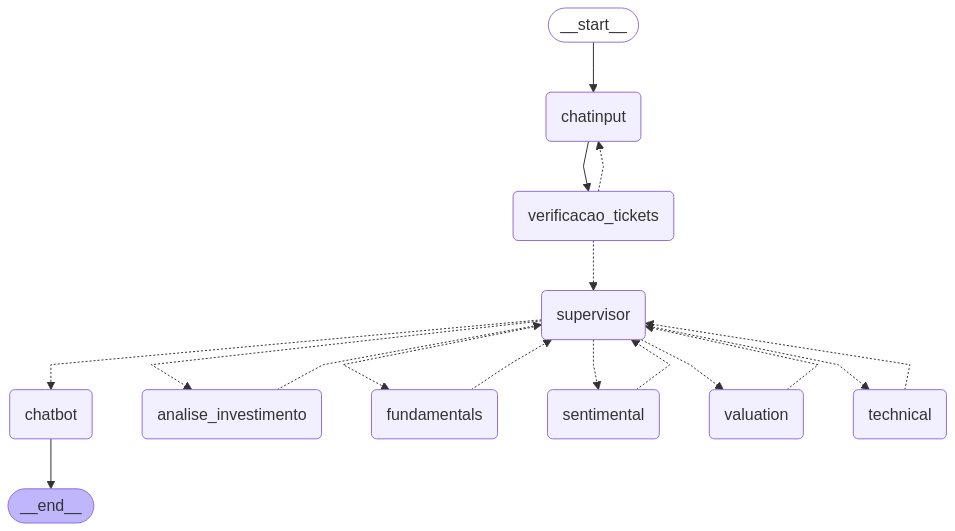

In [18]:
#https://github.com/langchain-ai/langchain/issues/30427
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [19]:
graph.get_graph().print_ascii()

                                                                      +-----------+                                                                  
                                                                      | __start__ |                                                                  
                                                                      +-----------+                                                                  
                                                                             *                                                                       
                                                                             *                                                                       
                                                                             *                                                                       
                                                                      +-----------+                 

In [20]:
import time
user_input = [
    # Saudações gerais
    "Bom dia, como está?",
    "Olá, poderia me ajudar?",
    "Boa tarde, gostaria de algumas análises",
    "Oi, preciso de ajuda com investimentos",
    
    # Análises Técnicas
    "Realize uma análise técnica da PETROBRAS",
    "Quero ver a análise técnica da VALE",
    "Me mostre os indicadores técnicos da ITUB4",
    "Poderia fazer uma análise técnica da Banco do BRASIL?",
    "Como está o gráfico técnico da MAGAZ LUIZA?",
    
    # Análises Fundamentalistas
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Preciso dos fundamentos da PETROBRAS",
    "Qual a análise fundamental da VALE?",
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Faça uma análise fundamentalista da ITAU",
    "Como estão os fundamentos da WEG?",
    
    # Análises de Sentimento
    "Qual o sentimento do mercado sobre Unifique?",
    "Análise de sentimento para VALE, por favor",
    "Como está o sentimento para MULTIPLAN?",
    "Faça uma análise de sentimento da OI",
    "Qual a percepção do mercado sobre PETZ?",
    
    # Análises de Valuation
    "Qual o valor justo da AMERICANAS?",
    "Faça uma análise de valuation do Banco do AMAZONIA",
    "Preciso do valuation da BANDO MERCANTIL",
    "Me ajude com o valuation da ECORODOVIAS",
    "Quanto vale realmente a CEMIG?",
    
    # Combinações de Análises
    "Quero análise técnica e fundamental da PETR4",
    "Mostre o sentimento e valuation da VALE3",
    "Preciso de uma análise completa da BBDC3",
    "Como está BRASKEM em termos técnicos e sentimentais?",

    
    # Perguntas Específicas
    
    "Qual o melhor momento para comprar PETR4?",
    "Devo vender minha posição em GERDAU?",
    "É hora de investir em BRAVA?",
    "FLEURY está cara ou barata?",
    "Vale a pena entrar em MAGAZIN LUIZA agora?"
]

#user_input = ["Como está BRASKEM em fundamental e tecnica?"]

    # Configuração do stream
config = {"configurable": {"thread_id": "1"}}

for mess in user_input:
        # Configuração inicial do estado
    print('Pergunta feita:',mess)
    try:
        start = time.time()
        initial_state = {
                "messages": [HumanMessage(content=mess)],
                "ticker": "", 
                "method_analysis": "" ,
                "dados_input" : "",
                "next" : ""
                
            }
    
        events = await graph.ainvoke(
                initial_state,
                config=config,
                stream_mode="values",
            )
        end = time.time()
        
    except:
        print('Erro na execucao')
        pass
    
    print('-'* 100)
    
    

Pergunta feita: Bom dia, como está?
Entrei na chat imput
Ticker extraído: 
Método de análise: ['chatbot']
Entrei na verificaçao de tickets
Entrei no supervisor
Entrei no chat bot
Dados input: 
O tamanho do dados input é: 0
----------------------------------------------------------------------------------------------------
Pergunta feita: Olá, poderia me ajudar?
Entrei na chat imput
Ticker extraído: 
Método de análise: ['chatbot']
Entrei na verificaçao de tickets
Entrei no supervisor
Entrei no chat bot
Dados input: 
O tamanho do dados input é: 0
----------------------------------------------------------------------------------------------------
Pergunta feita: Boa tarde, gostaria de algumas análises
Entrei na chat imput
Ticker extraído: 
Método de análise: ['chatbot']
Entrei na verificaçao de tickets
Entrei no supervisor
Entrei no chat bot
Dados input: 
O tamanho do dados input é: 0
----------------------------------------------------------------------------------------------------
Perg

[*********************100%***********************]  1 of 1 completed


Nao tem returnOnEquity
Diferença entre valuation e cotação: nan%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Entrei no supervisor
Todos os métodos de análise concluídos
Entrei no chat bot
Dados input: [HumanMessage(content="\n############Valuation Analysis############\n\nThe Americanas (AMER3.SA) valuation analysis presents discrepancies between the Gordon Growth Model and the Discounted Cash Flow (DCF) model.\n\n**Comparison:**\n- The Gordon Growth Model valuation is not available (NaN).\n- The DCF valuation is R$ 17.29, while the current stock price is R$ 6.01.\n\n**Discrepancies and Influencing Factors:**\nThe DCF model's higher valuation might be due to the model's sensitivity to inputs, such as revenue growth, EBIT margins, and WACC.\n\n**Profitability & Sustainability:**\n- The company reports negative EBIT (-R$ 2.90B in 2025) and significant CAPEX (R$ 5.09B in 2025).\n- Future cash flows may be jeopardized by high CAPEX.\n\n**Risks & Inconsistencies:**\n- Revenue growth sustainability is a concern.\n- High debt levels and debt-to-cash ratio require attention.\n- WACC (2.00%) seems low.

...

Entrei no supervisor
Todos os métodos de análise concluídos
Entrei no chat bot
Dados input: [HumanMessage(content="\n############Valuation Analysis############\n\nFleury's stock price is currently R$ 13.04. The Gordon Growth Model estimates a stock price of R$ 9.71, while the DCF Model estimates R$ 30.13.\n\n**Comparison:** The significant discrepancy between the two valuations (R$ 9.71 vs R$ 30.13) may be due to differences in assumptions, such as growth rates, discount rates, and cash flow projections.\n\n**Profitability & Sustainability:** Fleury generates positive cash flow, but high CAPEX (R$ 681.65M in 2025) may impact future cash flows. The company's EBIT margin is 17.48%, indicating reasonable profitability.\n\n**Risks & Inconsistencies:** Revenue growth sustainability and debt levels (R$ 2.29B) are concerns. The debt-to-cash ratio is 0.98x, which is manageable. The WACC of 5.47% seems reasonable.\n\n**Conclusion & Recommendation:** Based on the DCF valuation, Fleury appears un

[*********************100%***********************]  1 of 1 completed


Diferença entre valuation e cotação: -15.91%


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Error fetching URL: Client error '403 Forbidden' for url 'https://br.investing.com/news/stock-market-news/ibovespa-opera-estavel-com-ipca15-compensando-desempenho-negativo-de-vale-1529769'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403
Error fetching URL: Redirect response '301 Moved Permanently' for url 'https://www.msn.com/pt-br/dinheiro/economia-e-negocios/bom-dia-advfn-com-press%c3%a3o-de-trump-powell-poder%c3%a1-antecipar-a-queda-dos-juros-ipca-15-vale-tem-queda-de-17-no-lucro/ar-AA1DBreG'
Redirect location: 'https://www.msn.com/'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/301
Entrei no supervisor
Todos os métodos de análise concluídos
Entrei no chat bot
Dados input: [HumanMessage(content="#########Technical Analysis#######\nBased on the provided data, here's a concise analysis of MGLU3:\n\n**Trend Identification:** \nThe price is below the 20, 100, and 200 period moving averages, indicating a down

In [21]:
from langchain_core.prompts import ChatPromptTemplate

state = graph.get_state(config)

ChatPromptTemplate.from_messages(state.values["messages"]).pretty_print()

================================ Human Message =================================

Bom dia, como está?

================================== Ai Message ==================================


<think>
Okay, the user greeted me with "Bom dia, como está?" which means "Good morning, how are you?" in Portuguese. I should respond politely in Portuguese. Let me check the guidelines again to make sure I follow them. The user hasn't provided any specific data yet, so my response should be friendly and prompt them to provide the necessary information for the analysis. I need to mention that I'm here to help with investment analysis and ask them to share the data so I can proceed. Also, remember to keep it concise and professional. Alright, time to put that together.
</think>

Bom dia! Estou aqui para ajudar. Como posso analisar suas informações? Por favor, forneça os dados das ações (no formato especificado) que deseja avaliar, incluindo as seções de **Technical Analysis**, **Fundamental Analysis**, *

In [60]:
ChatPromptTemplate.from_messages(state.values["dados_input"]).pretty_print()

================================ Human Message =================================
Name: tecnica


##########Fundamental Analysis########

Based on the provided financial data for Braskem (BRKM3), here's a concise analysis:

**Strengths:**
- Positive EBITDA in most quarters, indicating operational profitability.
- Reasonable revenue growth in some quarters.

**Weaknesses:**
- Consistent net losses and negative EBIT in several quarters, signaling operational challenges.
- High debt levels (e.g., 53230.0 and 44750.0) compared to equity, indicating potential leverage risks.
- Negative return on equity (e.g., -2.836 and -1.443) and return on invested capital.

**Valuation:**
- Negative P/E ratios across quarters, suggesting investor skepticism.
- EV/EBIT and EV/EBITDA ratios indicate potentially undervalued or distressed stock.

**Recommendation:** SELL (60% confidence)
Braskem's financials reveal operational inefficiencies, significant leverage, and investor concerns. While some quarters sh

In [20]:
ChatPromptTemplate.from_messages(state.values["method_analysis"]).pretty_print()

In [32]:
state.values["dados_input"][0].content

"#########Technical Analysis#######\nBased on the provided data, here's a concise analysis of MGLU3:\n\n**Trend Identification:** \nThe price is below the 20, 100, and 200 period moving averages, indicating a downtrend.\n\n**Market Strength:** \nThe 14-period RSI (around 31) suggests oversold conditions (<30).\n\n**Volatility:** \nBollinger Bands and ADX indicate low to moderate volatility.\n\n**Strategy:** \nConsider a buy strategy if the price bounces off the support levels (S1, S2, etc.) or breaks above the 20-period SMA.\n\n**Confidence Level:** 70% \n\nThe provided data indicates a downtrend with oversold conditions. A bounce-back or breakout above key moving averages could signal a trend reversal.##########Fundamental Analysis########\nBased on the provided financial data for MGLU3, here's a concise analysis:\n\n**Strengths:**\n- Revenue growth trend: Revenue has shown an increasing trend from 8580.0 to 11170.0 across the periods.\n- Gross margin stability: Gross margin has remai

## Agente junto

In [1]:
from langgraph_construcao import langgraph_main
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage
import time

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
graph_builder = langgraph_main()
memory = MemorySaver()
graph = graph_builder.compile(memory)

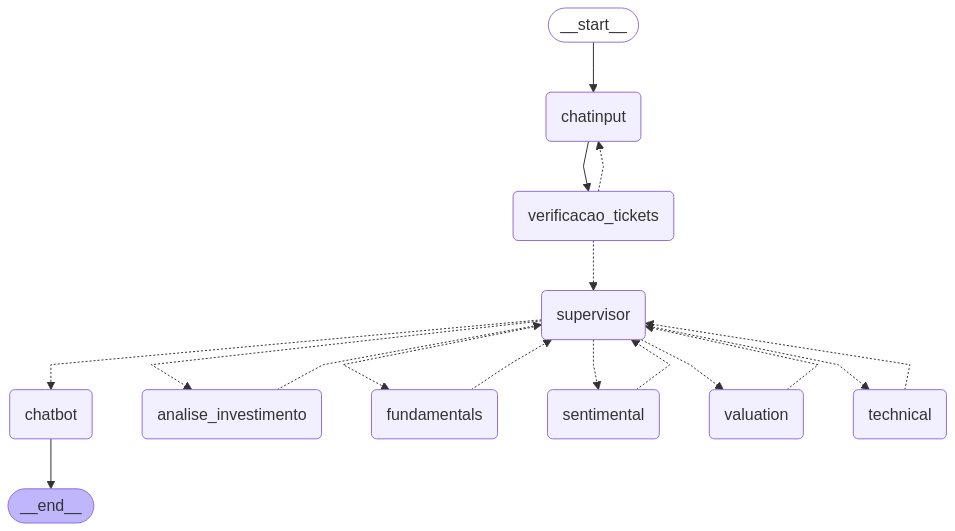

In [3]:
#https://github.com/langchain-ai/langchain/issues/30427
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [ ]:
user_input = [
    # Saudações gerais
    "Bom dia, como está?",
    "Olá, poderia me ajudar?",
    "Boa tarde, gostaria de algumas análises",
    "Oi, preciso de ajuda com investimentos",
    
    # Análises Técnicas
    "Realize uma análise técnica da PETROBRAS",
    "Quero ver a análise técnica da VALE",
    "Me mostre os indicadores técnicos da ITUB4",
    "Poderia fazer uma análise técnica da Banco do BRASIL?",
    "Como está o gráfico técnico da MAGAZ LUIZA?",
    
    # Análises Fundamentalistas
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Preciso dos fundamentos da PETROBRAS",
    "Qual a análise fundamental da VALE?",
    "Me mostre os indicadores fundamentalistas da BRADESCO",
    "Faça uma análise fundamentalista da ITAU",
    "Como estão os fundamentos da WEG?",
    
    # Análises de Sentimento
    "Qual o sentimento do mercado sobre Unifique?",
    "Análise de sentimento para VALE, por favor",
    "Como está o sentimento para MULTIPLAN?",
    "Faça uma análise de sentimento da OI",
    "Qual a percepção do mercado sobre PETZ?",
    
    # Análises de Valuation
    "Qual o valor justo da AMERICANAS?",
    "Faça uma análise de valuation do Banco do AMAZONIA",
    "Preciso do valuation da BANDO MERCANTIL",
    "Me ajude com o valuation da ECORODOVIAS",
    "Quanto vale realmente a CEMIG?",
    
    # Combinações de Análises
    "Quero análise técnica e fundamental da PETR4",
    "Mostre o sentimento e valuation da VALE3",
    "Preciso de uma análise completa da BBDC3",
    "Como está BRASKEM em termos técnicos e sentimentais?",

    
    # Perguntas Específicas
    
    "Qual o melhor momento para comprar PETR4?",
    "Devo vender minha posição em GERDAU?",
    "É hora de investir em BRAVA?",
    "FLEURY está cara ou barata?",
    "Vale a pena entrar em MAGAZIN LUIZA agora?"
]

#user_input = ["Como está BRASKEM em fundamental e tecnica?"]

    # Configuração do stream
config = {"configurable": {"thread_id": "1"}}

for mess in user_input:
        # Configuração inicial do estado
    print('Pergunta feita:',mess)
    try:
        start = time.time()
        initial_state = {
                "messages": [HumanMessage(content=mess)],
                "ticker": "", 
                "method_analysis": "" ,
                "dados_input" : "",
                "next" : ""
                
            }
    
        events = await graph.ainvoke(
                initial_state,
                config=config,
                stream_mode="values",
            )
        end = time.time()
        
    except Exception as e:
        print(f'Erro na execucao: {e}')
        pass
    
    print('-'* 100)
    
    

In [8]:
from langchain_core.prompts import ChatPromptTemplate

state = graph.get_state(config)

ChatPromptTemplate.from_messages(state.values["messages"]).pretty_print()

================================ Human Message =================================

Qual a analise tecnica da PETR4?

================================== Ai Message ==================================

A análise técnica da PETR4 indica:

- A ação está em uma forte tendência de alta, com o preço consistentemente acima das médias móveis de 20, 100 e 200 períodos.
- O RSI (Índice de Força Relativa) esteve majoritariamente acima de 70, indicando condições de sobrecompra, mas apresentou uma ligeira diminuição para 51,46 em 01/04/2025, sugerindo uma perda de momentum.
- As Bandas de Bollinger estão se ampliando e o ADX (Índice de Direção Média) está alto (>25), o que indica aumento da volatilidade.

**Recomendação:** Diante da tendência de alta e das condições de sobrecompra, sugere-se uma abordagem cautelosa. Considerar aguardar um recuo ou uma quebra abaixo da Banda de Bollinger inferior ou da média móvel simples de 20 períodos antes de comprar.

**Nível de Confiança:** 80%

**Observação:** A 

In [ ]:
from langchain_core.messages import HumanMessage
mess = "Qual a analise tecnica da PETR4?"
initial_state = {
                "messages": [HumanMessage(content=mess)],
                "ticker": "", 
                "method_analysis": "" ,
                "dados_input" : "",
                "next" : ""
                
            }

config = {"configurable": {"thread_id": "1"}}
    
events = await graph.ainvoke(
                initial_state,
                config=config,
                stream_mode="values",
            )

In [5]:
events

{'messages': [HumanMessage(content='Qual a analise tecnica da PETR4?', additional_kwargs={}, response_metadata={}, id='5567bab7-d206-49b0-b7e6-7fc3fd0d8793'),
  AIMessage(content='A análise técnica da PETR4 indica:\n\n- A ação está em uma forte tendência de alta, com o preço consistentemente acima das médias móveis de 20, 100 e 200 períodos.\n- O RSI (Índice de Força Relativa) esteve majoritariamente acima de 70, indicando condições de sobrecompra, mas apresentou uma ligeira diminuição para 51,46 em 01/04/2025, sugerindo uma perda de momentum.\n- As Bandas de Bollinger estão se ampliando e o ADX (Índice de Direção Média) está alto (>25), o que indica aumento da volatilidade.\n\n**Recomendação:** Diante da tendência de alta e das condições de sobrecompra, sugere-se uma abordagem cautelosa. Considerar aguardar um recuo ou uma quebra abaixo da Banda de Bollinger inferior ou da média móvel simples de 20 períodos antes de comprar.\n\n**Nível de Confiança:** 80%\n\n**Observação:** A tendênci